In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Parameters

In [2]:
g = 9.8
k = 0.1  #air resistance cofficent

v0 = 10
theta = np.radians(45)

vx = v0 * np.cos(theta)
vy = v0 * np.sin(theta)

dt = 0.01

## simulation

In [3]:
#withoug the air resstance 
x1,y1 = [0],[0]

while y1[-1] >= 0:
    v = np.sqrt(vx**2 + vy**2)

    ax = 0
    ay = -g

    vx += ax * dt
    vy += ay * dt

    x1.append(x1[-1] + vx*dt)
    y1.append(y1[-1] + vy*dt)

    

In [4]:
#making the velocity reset 
vx = v0 * np.cos(theta)
vy = v0 * np.sin(theta)

#with air resistance
x2,y2 = [0],[0]

while y2[-1] >= 0:
    v = np.sqrt(vx**2 + vy**2)

    ax =  -k * v * vx
    ay =  -g - k*v*vy
    
    vx += ax * dt
    vy += ay * dt
    
    x2.append(x2[-1] + vx*dt)
    y2.append(y2[-1] + vy*dt)




## Plot

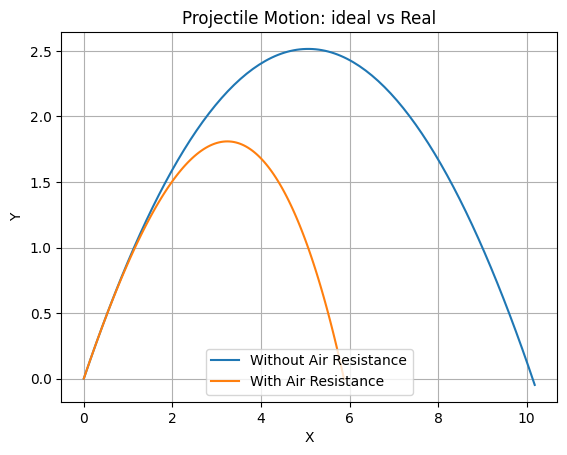

In [5]:
plt.plot(x1,y1,label="Without Air Resistance")
plt.plot(x2,y2,label="With Air Resistance")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Projectile Motion: ideal vs Real")
plt.legend()
plt.grid()
plt.show()

## Comparing diffrent range 

In [48]:
#making a rnage computing function

#With the air drag
def get_range(v0=30,theta=45,k=0.5,dt=0.01):
    g = 9.8
    theta_t = np.radians(theta)

    vx = v0 * np.cos(theta_t)
    vy = v0 * np.sin(theta_t)

    x,y = 0,0

    while y >= 0:
        v = np.sqrt(vx**2 + vy**2)

        ax = -k*v*vx
        ay = -g-k*v*vy

        vx +=ax * dt
        vy +=ay * dt

        x += vx * dt
        y += vy * dt

    return x    


In [49]:
#making a rnage computing function withoug the drag 
def get_range_wt(v0,k=0.5,dt=0.01):
    g = 9.8
    theta=np.radians(45)

    vx = v0 * np.cos(theta)
    vy = v0 * np.sin(theta)

    x,y = 0,0

    while y >= 0:
        v = np.sqrt(vx**2 + vy**2)

        ax = 0
        ay = -g

        vx +=ax * dt
        vy +=ay * dt

        x += vx * dt
        y += vy * dt

    return x    


In [50]:
v_values = [5,10,15,20,25,30]
ranges = []
ranges_2 = []
for v in v_values:
    r = get_range(v)
    r2 = get_range_wt(v)
    ranges.append(r)
    ranges_2.append(r2)
    print(f"v0={v}, range={r:.2f}, range_2={r2:.2f}")


v0=5, range=1.32, range_2=2.55
v0=10, range=2.47, range_2=10.18
v0=15, range=3.15, range_2=22.91
v0=20, range=3.59, range_2=40.73
v0=25, range=3.91, range_2=63.64
v0=30, range=4.16, range_2=91.64


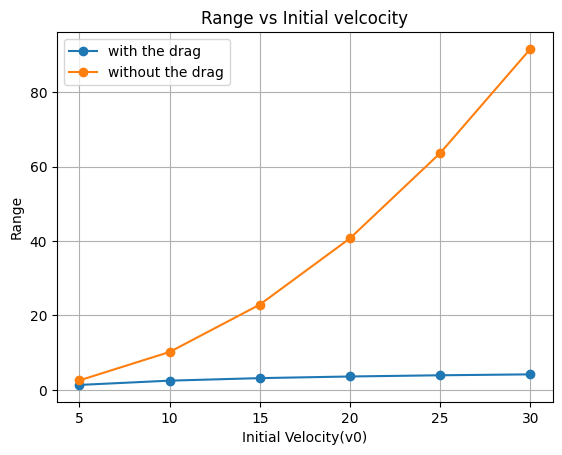

In [51]:
plt.plot(v_values,ranges,marker = 'o',label="with the drag")
plt.plot(v_values, ranges_2,marker = 'o',label="without the drag")
plt.xlabel("Initial Velocity(v0)")
plt.ylabel("Range")
plt.title("Range vs Initial velcocity")

plt.grid()
plt.legend()
plt.show()

## Finding the optimal angel for maximum distance

In [54]:
#Find the angle for maximum range 

theta_values = np.linspace(5,100,20)
ranges = []


for v in theta_values:
    
    r= get_range(20,v)
    ranges.append(r)

    print(f"theta={v}, range={r:.2f}")

theta=5.0, range=2.30
theta=10.0, range=3.00
theta=15.0, range=3.42
theta=20.0, range=3.68
theta=25.0, range=3.81
theta=30.0, range=3.85
theta=35.0, range=3.82
theta=40.0, range=3.74
theta=45.0, range=3.59
theta=50.0, range=3.39
theta=55.0, range=3.14
theta=60.0, range=2.83
theta=65.0, range=2.47
theta=70.0, range=2.07
theta=75.0, range=1.61
theta=80.0, range=1.11
theta=85.0, range=0.57
theta=90.0, range=0.00
theta=95.0, range=-0.57
theta=100.0, range=-1.11


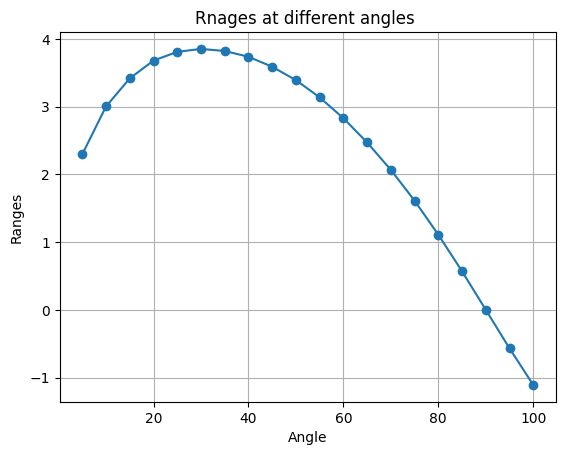

In [55]:

plt.plot(theta_values,ranges,marker='o')
plt.xlabel("Angle")
plt.ylabel("Ranges")
plt.title("Rnages at different angles ")

plt.grid()

plt.show()

In [56]:
#find the angle for maximum range
best_index = np.argmax(ranges)  #find the index of  maximum value
best_angle = theta_values[best_index]  #find the angle for maximum range
best_range = ranges[best_index] #value of max range

print(f"Best angle = {best_angle:.2f}, Range= {best_range:.2f} meter")


Best angle = 30.00, Range= 3.85 meter
